PREDICTIVE MODELING FOR BEAN NUTRIENTS
WITH PCA DIMENSIONALITY REDUCTION FOR NIR

1. LOADING DATA...
ICP-OES shape: (144, 11)
pXRF shape: (144, 13)
NIR shape: (144, 2152)

2. MERGING DATASETS BY ID...
Merged data shape: (144, 2174)
Samples with complete data: 144

3. APPLYING PCA TO NIR SPECTRA...
pXRF features: 12
NIR features: 2151

✅ PCA completed:
   - Total variance explained by 10 PCs: 99.20%
   - Components needed for 95% variance: 5
   - Variance explained by 5 PCs: 96.30%

4. GENERATING PCA PLOTS...


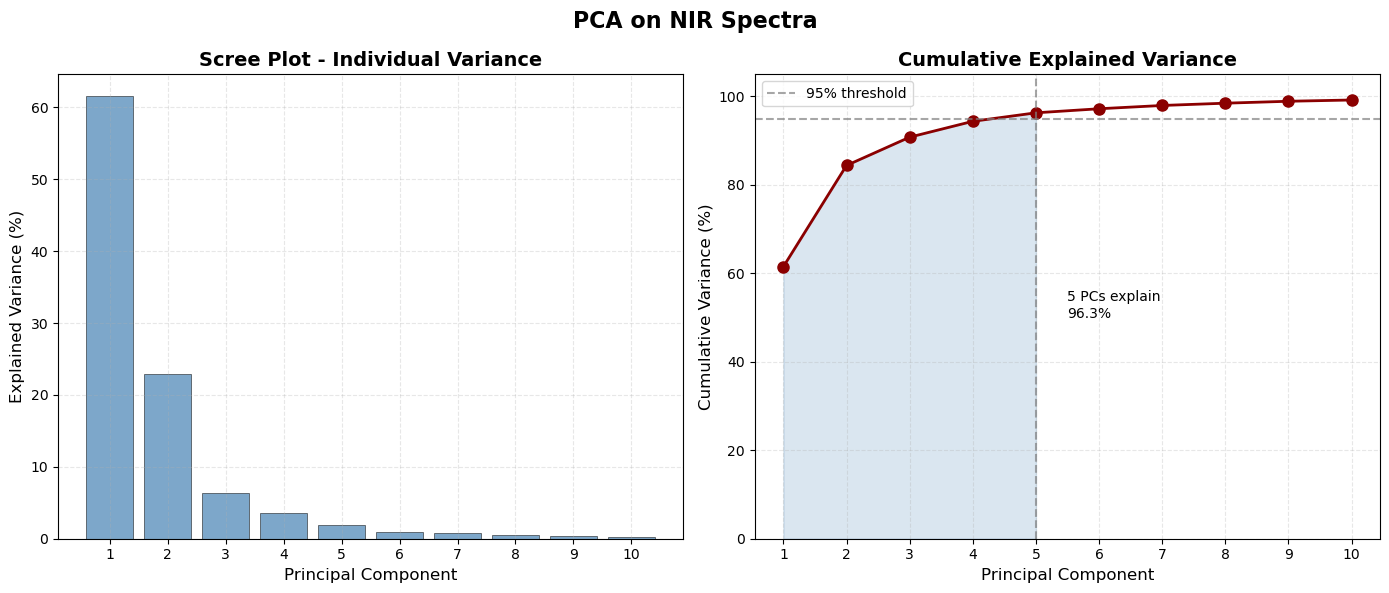

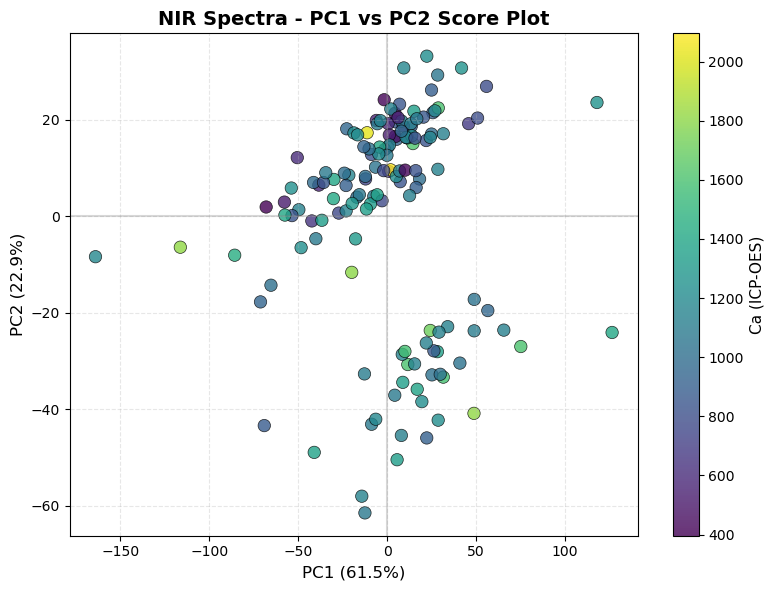

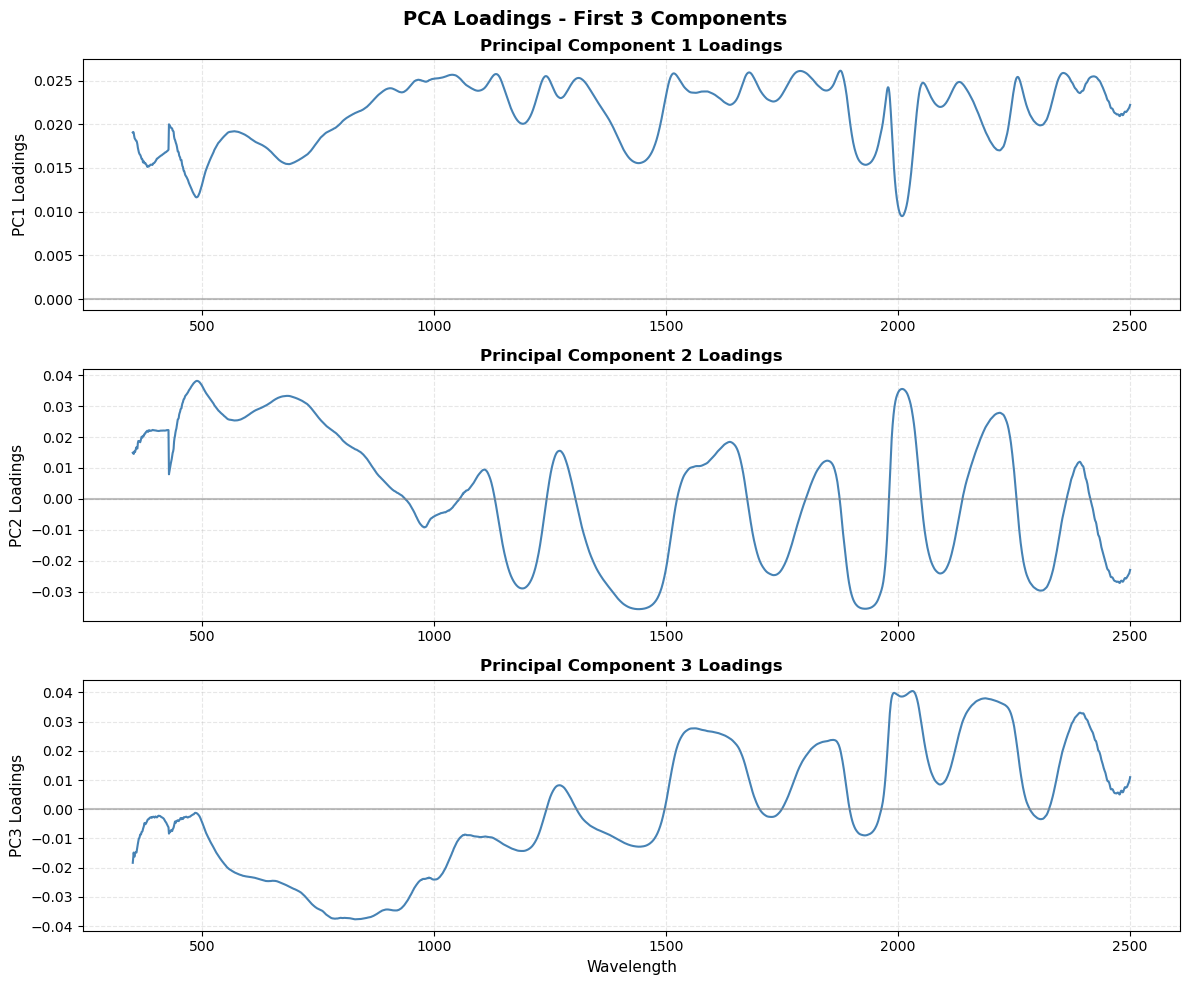


5. SEPARATING FEATURES AND TARGETS...
Available targets: ['Ca', 'Cu', 'Fe', 'K', 'Mn', 'P', 'S', 'Zn', 'Se', 'N']
pXRF features: 12
NIR PCA features (95% variance): 5

6. RUNNING MODELS WITH 10x5-FOLD CROSS-VALIDATION...

--- Analyzing: pXRF ---
  Target: Ca
  Target: Cu
  Target: Fe
  Target: K
  Target: Mn
  Target: P
  Target: S
  Target: Zn
  Target: Se
  Target: N

--- Analyzing: NIR_PCA ---
  Target: Ca
  Target: Cu
  Target: Fe
  Target: K
  Target: Mn
  Target: P
  Target: S
  Target: Zn
  Target: Se
  Target: N

--- Analyzing: pXRF+NIR_PCA ---
  Target: Ca
  Target: Cu
  Target: Fe
  Target: K
  Target: Mn
  Target: P
  Target: S
  Target: Zn
  Target: Se
  Target: N

✅ Results saved to prediction_results_icp_pxrf_nir_pca/all_predictions_summary.csv

7. CREATING SUMMARY TABLES...
✅ R² summary table saved
✅ RPD summary table saved

8. GENERATING HEATMAPS...


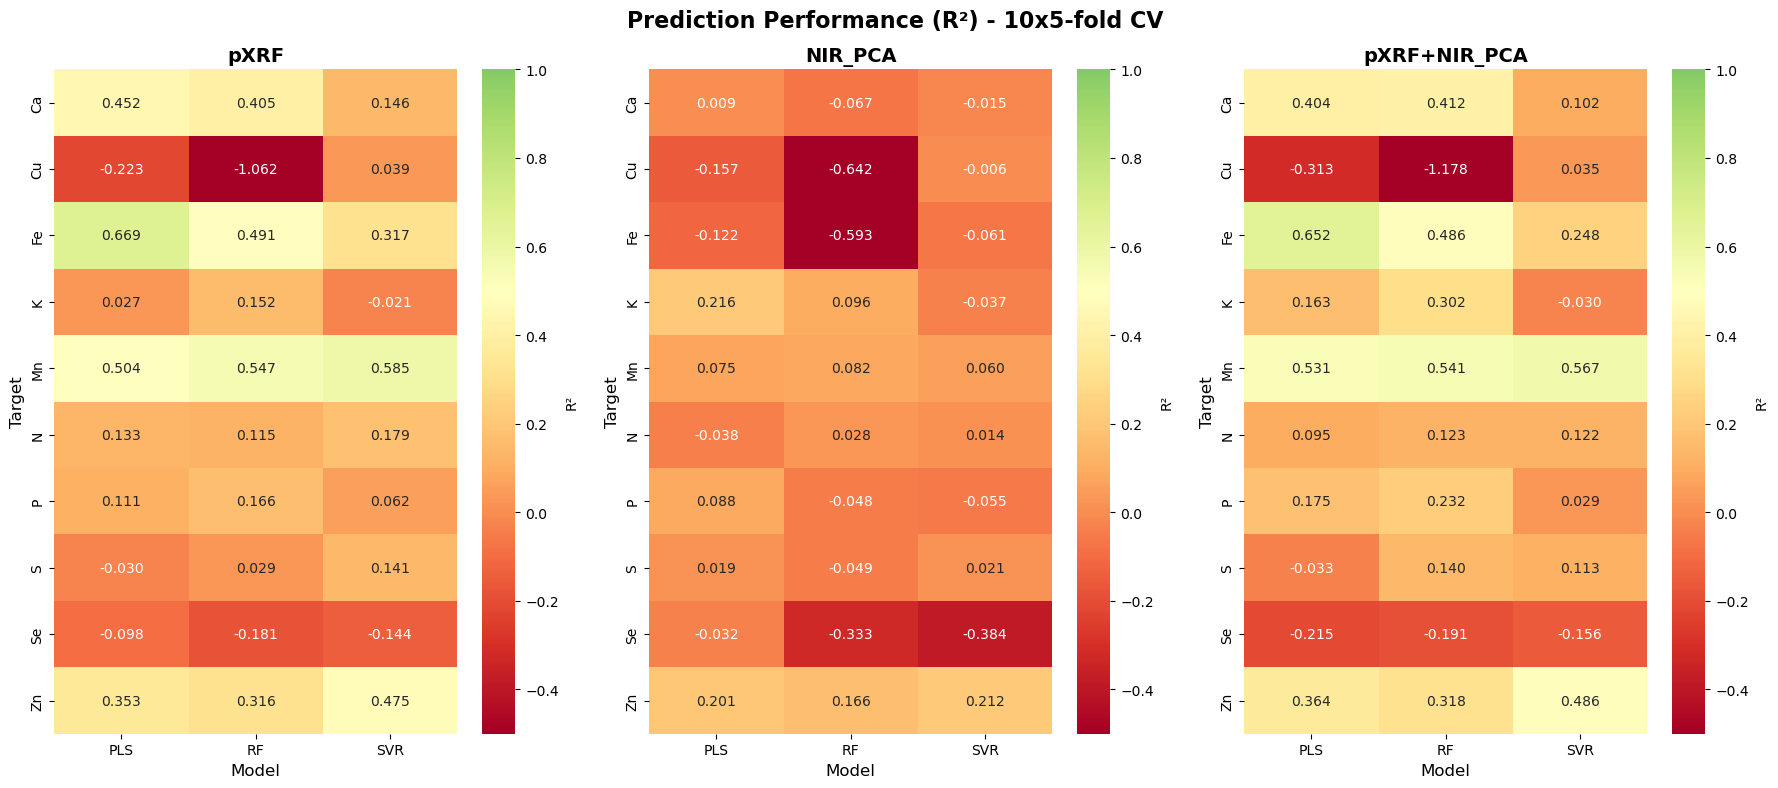

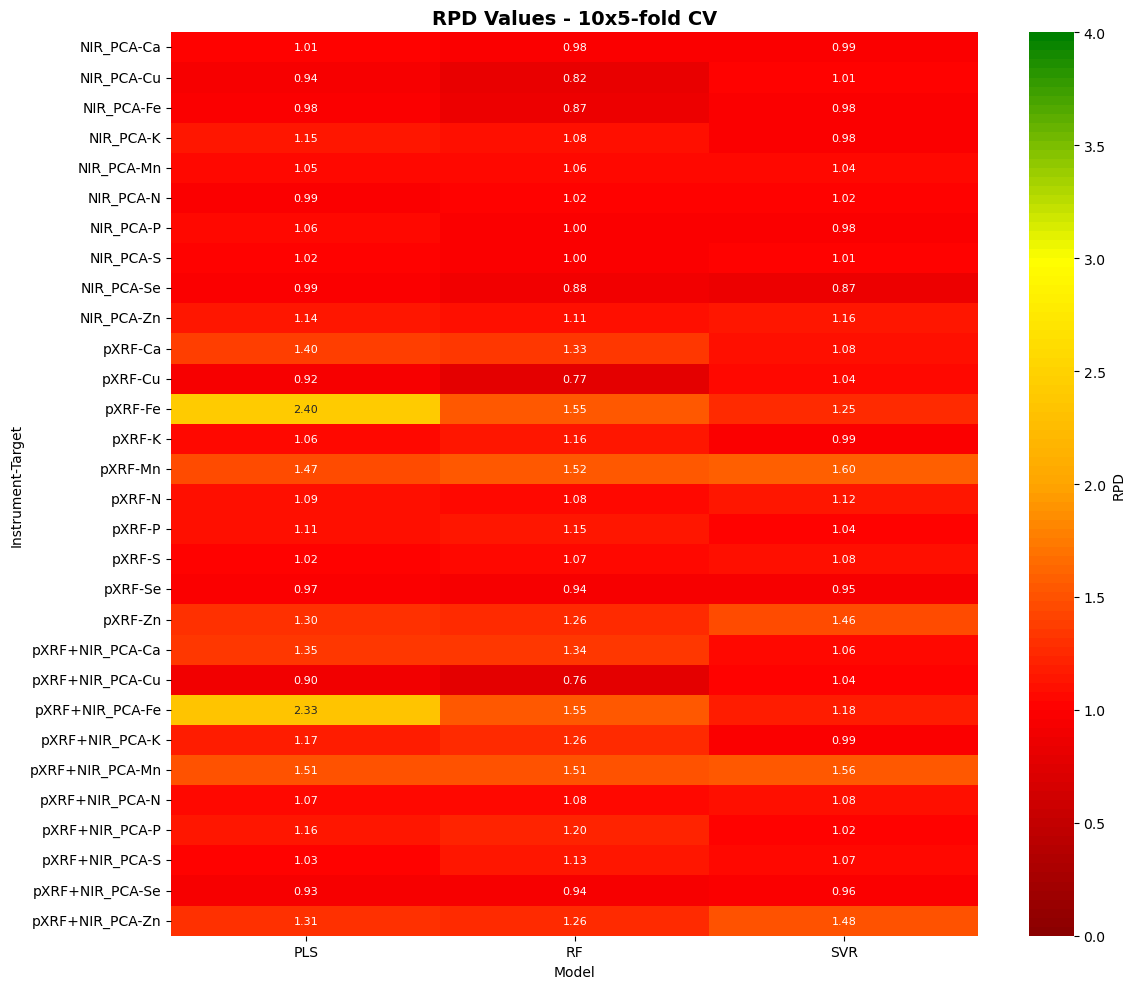


9. BEST MODEL FOR EACH TARGET...

📊 BEST MODELS SUMMARY:
Target   Instrument Model   R2_mean  RPD_mean   RMSE_mean
    Ca         pXRF   PLS  0.452401  1.395356  225.136623
    Cu         pXRF   SVR  0.038857  1.044595    3.105641
    Fe         pXRF   PLS  0.668882  2.401789   13.926677
     K pXRF+NIR_PCA    RF  0.301678  1.263783 1017.800654
    Mn         pXRF   SVR  0.585403  1.596903    1.766755
     P pXRF+NIR_PCA    RF  0.232389  1.204947  316.741360
     S         pXRF   SVR  0.140887  1.084403  129.361418
    Zn pXRF+NIR_PCA   SVR  0.485510  1.481578    4.920731
    Se      NIR_PCA   PLS -0.032097  0.987618    0.874736
     N         pXRF   SVR  0.179185  1.122050    2.889537

✅ Complete report saved to prediction_results_icp_pxrf_nir_pca/complete_report.txt

ANALYSIS COMPLETED SUCCESSFULLY!


In [1]:
# ====================================================
# PREDICTIVE MODELING FOR BEAN NUTRIENTS
# ICP-OES (reference) vs pXRF and NIR spectroscopy
# WITH PCA DIMENSIONALITY REDUCTION FOR NIR
# Algorithms: PLS, SVR, Random Forest
# Validation: 10x5-fold cross-validation
# ====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import os
import warnings
warnings.filterwarnings('ignore')

# Set working directory (adjust as needed)
base_path = "D:/Marcelo_Posdoc/PosDocFAPESP/Miscelaneous_PosDoc/Art_Marcelo&Filipe"
os.chdir(base_path)

# Create output folder
output_folder = "prediction_results_icp_pxrf_nir_pca"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print("="*60)
print("PREDICTIVE MODELING FOR BEAN NUTRIENTS")
print("WITH PCA DIMENSIONALITY REDUCTION FOR NIR")
print("="*60)

# 1. LOAD DATA (with semicolon separator)
# ----------------------------------------------------
print("\n1. LOADING DATA...")
icp_data = pd.read_csv("icp_oes.csv", sep=';')
pxrf_data = pd.read_csv("pxrf.csv", sep=';') 
nir_data = pd.read_csv("nir.csv", sep=';')

print(f"ICP-OES shape: {icp_data.shape}")
print(f"pXRF shape: {pxrf_data.shape}")
print(f"NIR shape: {nir_data.shape}")

# 2. MERGE DATASETS BY ID
# ----------------------------------------------------
print("\n2. MERGING DATASETS BY ID...")
# Assuming first column is 'ID' in all files
id_col = icp_data.columns[0]  # Get ID column name

# Merge all datasets
data = icp_data.merge(pxrf_data, on=id_col, how='inner')
data = data.merge(nir_data, on=id_col, how='inner')

print(f"Merged data shape: {data.shape}")
print(f"Samples with complete data: {len(data)}")

# 3. PCA ON NIR SPECTRA
# ----------------------------------------------------
print("\n3. APPLYING PCA TO NIR SPECTRA...")

# Define features for each instrument
pxrf_cols = [col for col in pxrf_data.columns if col != id_col]
nir_cols = [col for col in nir_data.columns if col != id_col]

print(f"pXRF features: {len(pxrf_cols)}")
print(f"NIR features: {len(nir_cols)}")

# Extract NIR spectra
nir_spectra = data[nir_cols].values

# Standardize NIR spectra before PCA
scaler_nir = StandardScaler()
nir_scaled = scaler_nir.fit_transform(nir_spectra)

# Apply PCA with max 10 components
pca = PCA(n_components=10)
nir_pca_scores = pca.fit_transform(nir_scaled)

# Determine number of components that explain 95% variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\n✅ PCA completed:")
print(f"   - Total variance explained by 10 PCs: {cumulative_variance[-1]*100:.2f}%")
print(f"   - Components needed for 95% variance: {n_components_95}")
print(f"   - Variance explained by {n_components_95} PCs: {cumulative_variance[n_components_95-1]*100:.2f}%")

# Create DataFrame with PC scores
pc_columns = [f'PC{i+1}' for i in range(10)]
nir_pca_df = pd.DataFrame(nir_pca_scores, columns=pc_columns)

# Add PC scores to data (will use for modeling)
for i, pc in enumerate(pc_columns):
    data[pc] = nir_pca_scores[:, i]

# 4. PCA VISUALIZATION
# ----------------------------------------------------
print("\n4. GENERATING PCA PLOTS...")

# Set style for minimalistic plots
plt.style.use('default')
sns.set_palette("husl")

# 4.1 Scree plot (explained variance)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot of explained variance
axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10] * 100, 
            color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('Scree Plot - Individual Variance', fontweight='bold', fontsize=14)
axes[0].set_xticks(range(1, 11))
axes[0].grid(True, alpha=0.3, linestyle='--')

# Cumulative variance line plot
axes[1].plot(range(1, 11), cumulative_variance[:10] * 100, 
             'o-', color='darkred', linewidth=2, markersize=8)
axes[1].axhline(y=95, color='gray', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].axvline(x=n_components_95, color='gray', linestyle='--', alpha=0.7)
axes[1].fill_between(range(1, n_components_95+1), 
                      cumulative_variance[:n_components_95] * 100, 
                      alpha=0.2, color='steelblue')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontweight='bold', fontsize=14)
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle='--')

# Add text annotation
axes[1].text(n_components_95 + 0.5, 50, 
             f'{n_components_95} PCs explain\n{cumulative_variance[n_components_95-1]*100:.1f}%',
             fontsize=10, ha='left')

plt.suptitle('PCA on NIR Spectra', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_folder}/pca_scree_plot.png", dpi=500, bbox_inches='tight')
plt.show()

# 4.2 Score plot (PC1 vs PC2) - colored by first target for visualization
# Use first available target for coloring
first_target = [t for t in ['Ca', 'Cu', 'Fe', 'K', 'Mn', 'P', 'S', 'Zn', 'Se', 'N'] 
                if t in data.columns][0]

fig, ax = plt.subplots(figsize=(8, 6))

# Create scatter plot with color gradient by target value
sc = ax.scatter(nir_pca_scores[:, 0], nir_pca_scores[:, 1], 
                c=data[first_target], cmap='viridis', 
                s=80, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(f'{first_target} (ICP-OES)', fontsize=11)

# Labels with variance explained
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('NIR Spectra - PC1 vs PC2 Score Plot', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_folder}/pca_scores_pc1_pc2.png", dpi=500, bbox_inches='tight')
plt.show()

# 4.3 Loadings plot (first 3 PCs)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Get wavelength information if available (assuming column names are wavelengths)
# If column names are not numeric, just use index
try:
    wavelengths = [float(col) for col in nir_cols]
    xlabel = 'Wavelength'
except:
    wavelengths = range(len(nir_cols))
    xlabel = 'Variable Index'

for i, ax in enumerate(axes):
    pc_loadings = pca.components_[i]
    ax.plot(wavelengths, pc_loadings, linewidth=1.5, color='steelblue')
    ax.set_ylabel(f'PC{i+1} Loadings', fontsize=11)
    ax.set_title(f'Principal Component {i+1} Loadings', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

axes[-1].set_xlabel(xlabel, fontsize=11)
plt.suptitle('PCA Loadings - First 3 Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_folder}/pca_loadings.png", dpi=500, bbox_inches='tight')
plt.show()

# 5. SEPARATE FEATURES AND TARGETS
# ----------------------------------------------------
print("\n5. SEPARATING FEATURES AND TARGETS...")

# Define target elements (from ICP-OES)
targets = ['Ca', 'Cu', 'Fe', 'K', 'Mn', 'P', 'S', 'Zn', 'Se', 'N']
# Check which targets actually exist in data
available_targets = [t for t in targets if t in data.columns]
print(f"Available targets: {available_targets}")

# Define feature sets for modeling
pxrf_features = pxrf_cols
nir_pca_features = [f'PC{i+1}' for i in range(n_components_95)]  # Use only PCs up to 95%

print(f"pXRF features: {len(pxrf_features)}")
print(f"NIR PCA features (95% variance): {len(nir_pca_features)}")

# 6. DEFINE METRICS FUNCTIONS
# ----------------------------------------------------
def calculate_metrics(y_true, y_pred):
    """Calculate R², RMSE, RPD and Bias"""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    if len(y_true) < 3:
        return {'R2': np.nan, 'RMSE': np.nan, 'RPD': np.nan, 'Bias': np.nan}
    
    # R²
    r2 = r2_score(y_true, y_pred)
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # RPD (Ratio of Performance to Deviation)
    sd = np.std(y_true)
    if rmse > 0:
        rpd = sd / rmse
    else:
        rpd = np.nan
    
    # Bias (mean error)
    bias = np.mean(y_pred - y_true)
    
    return {'R2': r2, 'RMSE': rmse, 'RPD': rpd, 'Bias': bias}

# 7. MODEL TRAINING AND EVALUATION FUNCTION
# ----------------------------------------------------
def evaluate_model(X, y, model, model_name, n_splits=5, n_repeats=10):
    """Evaluate model using repeated k-fold cross-validation"""
    
    # Initialize repeated k-fold
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    
    # Store results for each fold
    results = []
    
    for fold, (train_idx, test_idx) in enumerate(rkf.split(X)):
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model_clone.predict(X_test_scaled)
        
        # Calculate metrics
        metrics = calculate_metrics(y_test, y_pred)
        metrics['Fold'] = fold
        results.append(metrics)
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Calculate mean and std
    summary = {
        'Model': model_name,
        'R2_mean': results_df['R2'].mean(),
        'R2_std': results_df['R2'].std(),
        'RMSE_mean': results_df['RMSE'].mean(),
        'RMSE_std': results_df['RMSE'].std(),
        'RPD_mean': results_df['RPD'].mean(),
        'RPD_std': results_df['RPD'].std(),
        'Bias_mean': results_df['Bias'].mean(),
        'Bias_std': results_df['Bias'].std()
    }
    
    return summary, results_df

# 8. MAIN MODELING LOOP
# ----------------------------------------------------
print("\n6. RUNNING MODELS WITH 10x5-FOLD CROSS-VALIDATION...")

# Define models
models = {
    'PLS': PLSRegression(n_components=min(5, n_components_95)),
    'SVR': SVR(kernel='rbf', C=10, gamma='scale'),
    'RF': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

# Store all results
all_results = []

# Define instruments
instruments = {
    'pXRF': pxrf_features,
    'NIR_PCA': nir_pca_features,
    'pXRF+NIR_PCA': pxrf_features + nir_pca_features
}

for instrument_name, features in instruments.items():
    print(f"\n--- Analyzing: {instrument_name} ---")
    
    # Get feature matrix
    X = data[features].values
    
    for target in available_targets:
        print(f"  Target: {target}")
        
        # Get target values
        y = data[target].values
        
        # Remove samples with NaN in target
        mask = ~np.isnan(y)
        X_clean = X[mask]
        y_clean = y[mask]
        
        if len(y_clean) < 10:
            print(f"    Not enough samples: {len(y_clean)}. Skipping...")
            continue
        
        for model_name, model in models.items():
            # Evaluate model
            summary, fold_results = evaluate_model(X_clean, y_clean, model, model_name)
            
            # Add metadata
            summary['Instrument'] = instrument_name
            summary['Target'] = target
            
            # Store results
            all_results.append(summary)

# 9. CREATE RESULTS DATAFRAME
# ----------------------------------------------------
results_df = pd.DataFrame(all_results)

# Reorder columns
cols = ['Instrument', 'Target', 'Model', 
        'R2_mean', 'R2_std', 'RMSE_mean', 'RMSE_std', 
        'RPD_mean', 'RPD_std', 'Bias_mean', 'Bias_std']
results_df = results_df[cols]

# Save all results
results_df.to_csv(f"{output_folder}/all_predictions_summary.csv", index=False)
print(f"\n✅ Results saved to {output_folder}/all_predictions_summary.csv")

# 10. CREATE SUMMARY TABLES
# ----------------------------------------------------
print("\n7. CREATING SUMMARY TABLES...")

# Pivot table for R² by target and model
r2_pivot = results_df.pivot_table(
    values='R2_mean', 
    index=['Instrument', 'Target'], 
    columns='Model',
    aggfunc='first'
).round(3)

r2_pivot.to_csv(f"{output_folder}/r2_summary_table.csv")
print("✅ R² summary table saved")

# Pivot table for RPD
rpd_pivot = results_df.pivot_table(
    values='RPD_mean', 
    index=['Instrument', 'Target'], 
    columns='Model',
    aggfunc='first'
).round(3)

rpd_pivot.to_csv(f"{output_folder}/rpd_summary_table.csv")
print("✅ RPD summary table saved")

# 11. PLOTTING - HEATMAPS
# ----------------------------------------------------
print("\n8. GENERATING HEATMAPS...")

# Set style
plt.style.use('default')
sns.set_palette("husl")

# 11.1 Heatmap of R² values
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, instrument in enumerate(instruments.keys()):
    inst_data = results_df[results_df['Instrument'] == instrument]
    
    if len(inst_data) > 0:
        pivot_data = inst_data.pivot_table(
            values='R2_mean', 
            index='Target', 
            columns='Model',
            aggfunc='first'
        )
        
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn', 
                    vmin=-0.5, vmax=1, center=0.5, ax=axes[idx],
                    cbar_kws={'label': 'R²'}, annot_kws={'size': 10})
        axes[idx].set_title(f'{instrument}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Model', fontsize=12)
        axes[idx].set_ylabel('Target', fontsize=12)
    else:
        axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[idx].set_title(f'{instrument}', fontsize=14, fontweight='bold')

plt.suptitle('Prediction Performance (R²) - 10x5-fold CV', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_folder}/heatmap_r2.png", dpi=500, bbox_inches='tight')
plt.show()

# 11.2 RPD heatmap with interpretation colors
# Classify RPD
rpd_classes = []
for _, row in results_df.iterrows():
    rpd = row['RPD_mean']
    if rpd < 1.5:
        cls = 'Very poor (RPD < 1.5)'
    elif rpd < 2.0:
        cls = 'Poor (1.5-2.0)'
    elif rpd < 2.5:
        cls = 'Fair (2.0-2.5)'
    elif rpd < 3.0:
        cls = 'Good (2.5-3.0)'
    else:
        cls = 'Excellent (RPD > 3.0)'
    rpd_classes.append(cls)

results_df['RPD_Class'] = rpd_classes

# Create matrix of RPD values for heatmap
rpd_matrix = results_df.pivot_table(
    values='RPD_mean',
    index=['Instrument', 'Target'],
    columns='Model',
    aggfunc='first'
)

# Create custom colormap for RPD interpretation
from matplotlib.colors import LinearSegmentedColormap
colors = ['darkred', 'red', 'orange', 'yellow', 'green']
cmap = LinearSegmentedColormap.from_list('rpd_cmap', colors, N=100)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(rpd_matrix, annot=True, fmt='.2f', cmap=cmap,
            vmin=0, vmax=4, ax=ax,
            cbar_kws={'label': 'RPD'},
            annot_kws={'size': 8})
ax.set_title('RPD Values - 10x5-fold CV', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(f"{output_folder}/heatmap_rpd.png", dpi=500, bbox_inches='tight')
plt.show()

# 12. BEST MODEL SUMMARY
# ----------------------------------------------------
print("\n9. BEST MODEL FOR EACH TARGET...")

best_models = []
for target in available_targets:
    target_results = results_df[results_df['Target'] == target]
    if len(target_results) > 0:
        best_idx = target_results['R2_mean'].idxmax()
        best_models.append(target_results.loc[best_idx])

if best_models:
    best_df = pd.DataFrame(best_models)
    best_df = best_df[['Target', 'Instrument', 'Model', 'R2_mean', 'RPD_mean', 'RMSE_mean']]
    best_df.to_csv(f"{output_folder}/best_models.csv", index=False)
    
    print("\n📊 BEST MODELS SUMMARY:")
    print(best_df.to_string(index=False))

# 13. SAVE COMPLETE REPORT
# ----------------------------------------------------
with open(f"{output_folder}/complete_report.txt", 'w') as f:
    f.write("="*60 + "\n")
    f.write("PREDICTIVE MODELING REPORT - BEAN NUTRIENTS\n")
    f.write("WITH PCA DIMENSIONALITY REDUCTION FOR NIR\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total samples: {len(data)}\n")
    f.write(f"Targets: {', '.join(available_targets)}\n")
    f.write(f"pXRF features: {len(pxrf_cols)}\n")
    f.write(f"NIR features (original): {len(nir_cols)}\n")
    f.write(f"NIR PCA components (95% variance): {n_components_95}\n\n")
    
    f.write("PCA RESULTS:\n")
    f.write("-"*40 + "\n")
    for i in range(min(10, len(pca.explained_variance_ratio_))):
        f.write(f"PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}% (cumulative: {cumulative_variance[i]*100:.2f}%)\n")
    f.write(f"\nComponents for 95% variance: {n_components_95}\n\n")
    
    f.write("VALIDATION: 10x5-fold cross-validation\n\n")
    
    f.write("RPD INTERPRETATION:\n")
    f.write("-"*40 + "\n")
    f.write("RPD < 1.5: Very poor model (not recommended)\n")
    f.write("RPD 1.5 - 2.0: Poor model (rough screening)\n")
    f.write("RPD 2.0 - 2.5: Fair model (screening possible)\n")
    f.write("RPD 2.5 - 3.0: Good model (quantitative analysis)\n")
    f.write("RPD > 3.0: Excellent model (high precision)\n\n")
    
    f.write("BEST MODELS SUMMARY:\n")
    f.write("-"*40 + "\n")
    if best_models:
        for _, row in best_df.iterrows():
            f.write(f"{row['Target']}: {row['Instrument']} + {row['Model']} - "
                   f"R²={row['R2_mean']:.3f}, RPD={row['RPD_mean']:.2f}, RMSE={row['RMSE_mean']:.4f}\n")

print(f"\n✅ Complete report saved to {output_folder}/complete_report.txt")
print("\n" + "="*60)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*60)